In [ ]:
! pip install kaggle

In [ ]:
import numpy as np
import zipfile
from google.colab import drive
import os
import torch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive/')

# Копіюю kaggle.json в систему і надаю права
!mkdir -p ~/.kaggle
!cp '/content/drive/My Drive/Colab Notebooks/kaggle.json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
# Завантажую датасет Animals10
!kaggle datasets download alessiocorrado99/animals10

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0


In [ ]:
!unzip animals10.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: raw-img/ragno/OIP-MgrKq05YHGXsgj1AmYIyJQHaE8.jpeg  
  inflating: raw-img/ragno/OIP-MhRGx7d8nbnHBuqrsO00EQHaFo.jpeg  
  inflating: raw-img/ragno/OIP-MiVgMXcKGQdog2KGe7i0YQHaHh.jpeg  
  inflating: raw-img/r

In [ ]:
img_size = (227, 227)
batch_size = 32
extract_path="/content/raw-img"

datagen = ImageDataGenerator(
 rescale=1.0/255, # Нормалізація
 validation_split=0.25
)

In [ ]:
train_generator = datagen.flow_from_directory(
 extract_path,
 target_size=img_size,
 batch_size=batch_size,
 class_mode='categorical',
 subset='training',
 shuffle=True
)
val_generator = datagen.flow_from_directory(
 extract_path,
 target_size=img_size,
 batch_size=batch_size,
 class_mode='categorical',
 subset='validation',
 shuffle=True
)

Found 19638 images belonging to 10 classes.
Found 6541 images belonging to 10 classes.


In [ ]:
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,851,978 (98.62 MB)

 Trainable params: 25,851,978 (98.62 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(
 train_generator,
 epochs=10,
 validation_data=val_generator
)

Epoch 1/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.4206 - loss: 1.7098 - val_accuracy: 0.5097 - val_loss: 1.4749
Epoch 2/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 54s 88ms/step - accuracy: 0.4714 - loss: 1.5505 - val_accuracy: 0.5435 - val_loss: 1.3044
Epoch 3/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 59s 96ms/step - accuracy: 0.5284 - loss: 1.4062 - val_accuracy: 0.5779 - val_loss: 1.2229
Epoch 4/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 67s 109ms/step - accuracy: 0.5674 - loss: 1.2932 - val_accuracy: 0.6153 - val_loss: 1.1543
Epoch 5/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 54s 89ms/step - accuracy: 0.6054 - loss: 1.1598 - val_accuracy: 0.6199 - val_loss: 1.1290
Epoch 6/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6444 - loss: 1.0416 - val_accuracy: 0.6395 - val_loss: 1.0675
Epoch 7/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 61s 99ms/step - accuracy: 0.6733 - loss: 0.9678 - val_accuracy: 0.6530 - val_loss: 1.0427
Epoch 8/10
614/614 ━━━━━━━━━━━━━━━━━━━━ 58s 95ms/step - accuracy: 0.7042 - loss: 0.8718 -

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f"Точність на валідації: {accuracy:.4f}")
print(f"Втрати (Loss): {loss:.4f}")

205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.6727 - loss: 0.9981
Точність на валідації: 0.6710
Втрати (Loss): 1.0195


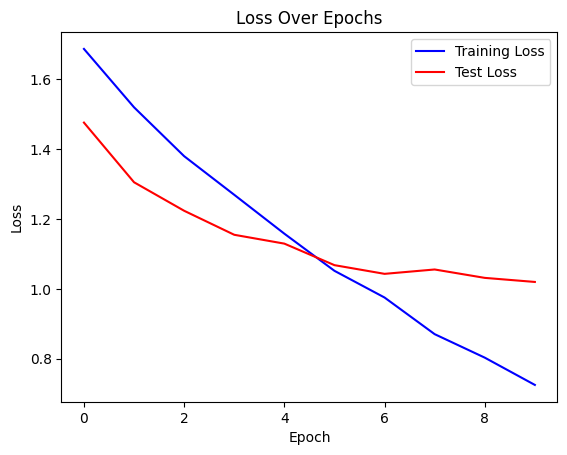

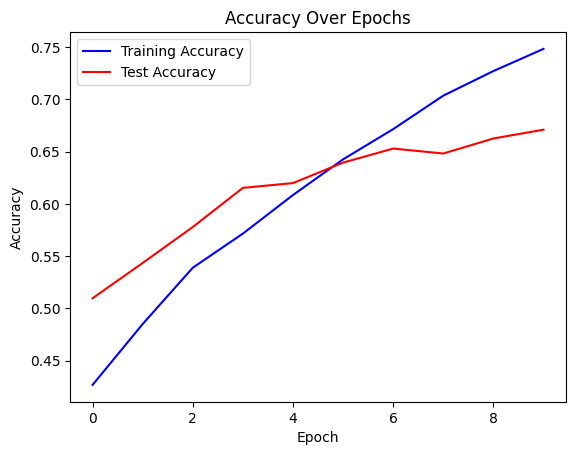

In [ ]:
plt.plot(history.history['loss'], color='b', label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], color='b', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='r', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

In [ ]:
images, labels = next(val_generator)

predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(labels, axis=1)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(24, 16))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    img = images[i]
    plt.imshow((img * 255).astype("uint8"))
    true_label = class_names[true_labels[i]]
    pred_label = class_names[predicted_labels[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.